# Day 4 control: reputation reward — quality vs conformity

Compares the two reputation reward modes on the same RoBERTa+SST-2
β-sweep — reads `outputs/day5_reputation.json` (or the IID variant).

- **loss** — `penalty_i = |L_i − L_min|`. Reputation tracks objective
  *quality* — the loss gap to the best agent (the §4 rule).
- **conformity** — `penalty_i = |L_i − L̄|`, with `L̄` the
  reputation-weighted mean loss. The literal lecture rule
  (`лекции/лекция2.md`, слайд 11: `r_i ← r_i/(γ + β·|x_i − X|)`):
  reputation rewards *proximity to consensus*, not quality.

The conformity arm is a **control**. Opinion-dynamics models use it
because they have no ground truth; an optimiser does (the loss).
Expected: conformity herds (reputation concentrates) **without** a
descent speed-up over FedAvg, and cascades at large β — which is
exactly why the loss-grounded rule is the real contribution.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
# Switch to 'day5_reputation_iid.json' for the IID-sharding run.
d = json.loads((ROOT / 'outputs' / 'day5_reputation_iid.json').read_text())
print('config:', d['config'])

# Split runs by reward mode. Runs predating the conformity branch have
# no 'mode' field -> treat them as 'loss'.
def mode_of(h):
    return h.get('mode', 'loss')

runs = d['runs']
loss_runs = dict(sorted(((k, v) for k, v in runs.items() if mode_of(v) == 'loss'),
                        key=lambda kv: kv[1]['beta']))
conf_runs = dict(sorted(((k, v) for k, v in runs.items() if mode_of(v) == 'conformity'),
                        key=lambda kv: kv[1]['beta']))
print(f"loss-mode β:       {[h['beta'] for h in loss_runs.values()]}")
print(f"conformity-mode β: {[h['beta'] for h in conf_runs.values()]}")
if not conf_runs:
    print('\n[!] No conformity runs in this JSON yet — rerun '
          'scripts/run_reputation.py to populate the conf_beta* keys.')

# Colour encodes β (shared scale across both modes); linestyle the mode.
all_betas = sorted({h['beta'] for h in runs.values()})
cmap = plt.get_cmap('viridis')
bcolor = {b: cmap(i / max(len(all_betas) - 1, 1)) for i, b in enumerate(all_betas)}
plt.rcParams['figure.dpi'] = 110

config: {'model': 'roberta-base', 'train_subset': 1000, 'probe_size': 32, 'total_steps': 5000, 'mezo_lr': 1e-06, 'mezo_eps': 0.001, 'eval_every': 500, 'n_agents': 8, 'local_steps': 100, 'sharding': 'iid', 'dirichlet_alpha': None, 'gamma_r': 1.0, 'agent_class_balance': [[62, 63], [56, 69], [48, 77], [55, 70], [55, 70], [57, 68], [49, 76], [58, 67]]}
loss-mode β:       [0.0, 0.1, 0.5, 1.0, 10.0]
conformity-mode β: [0.1, 0.5, 1.0, 10.0]


## Plot 1 — val accuracy & loss vs step

Quality reward = solid, conformity reward = dashed. If conformity gave
no real acceleration, its curves sit on or below the loss curves.

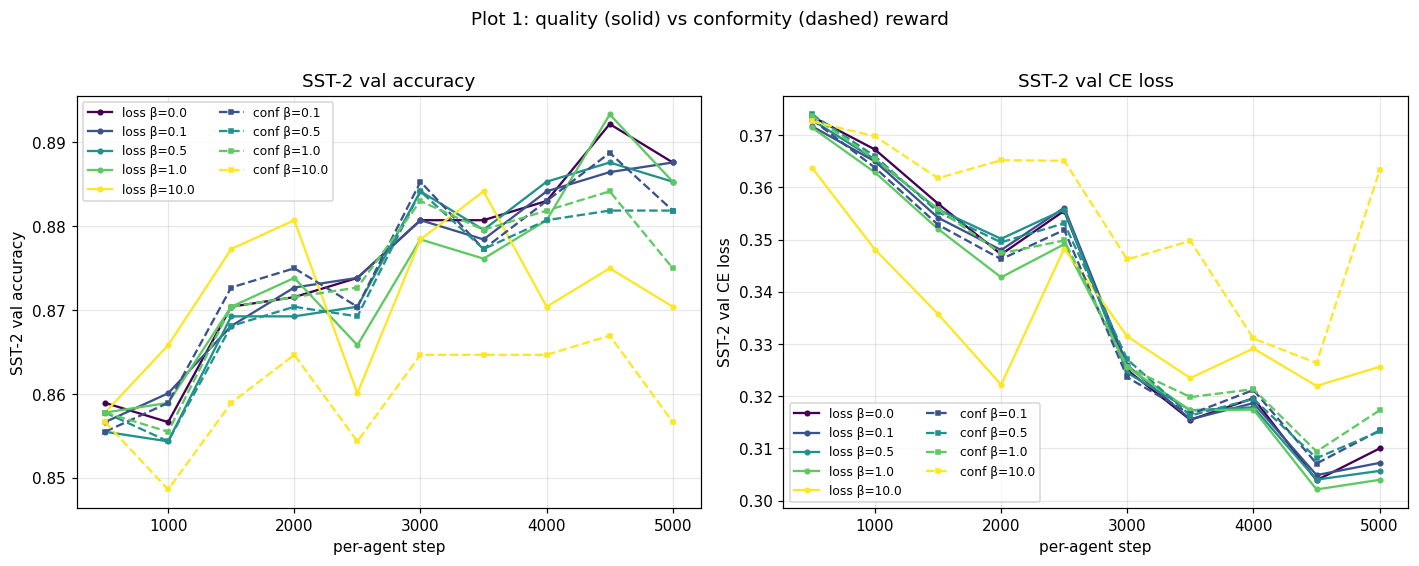

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in [(axes[0], 'eval_acc',  'SST-2 val accuracy'),
                        (axes[1], 'eval_loss', 'SST-2 val CE loss')]:
    for h in loss_runs.values():
        ax.plot(h['eval_step'], h[key], ls='-', marker='o', markersize=3,
                color=bcolor[h['beta']], label=f"loss β={h['beta']}")
    for h in conf_runs.values():
        ax.plot(h['eval_step'], h[key], ls='--', marker='s', markersize=3,
                color=bcolor[h['beta']], label=f"conf β={h['beta']}")
    ax.set_xlabel('per-agent step'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle('Plot 1: quality (solid) vs conformity (dashed) reward', y=1.02)
plt.tight_layout()

## Plot 2 — final val accuracy vs β (the headline)

Grouped bars per β. The `β=0` FedAvg baseline (dashed line) is shared:
at β=0 both modes collapse to it. The claim to read off: the loss bars
have a working window above the baseline; the conformity bars do not.

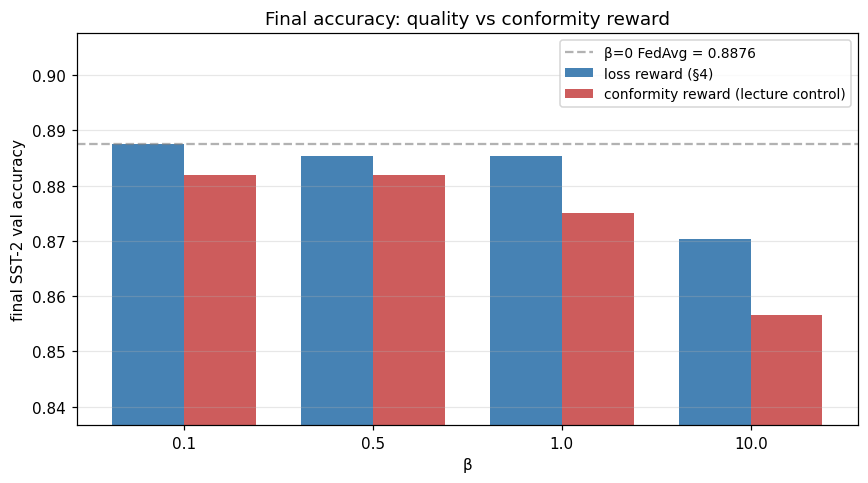

In [3]:
betas_cmp = sorted({h['beta'] for h in list(loss_runs.values())
                    + list(conf_runs.values()) if h['beta'] > 0})
loss_by_b = {h['beta']: h['eval_acc'][-1] for h in loss_runs.values()}
conf_by_b = {h['beta']: h['eval_acc'][-1] for h in conf_runs.values()}

x = np.arange(len(betas_cmp)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w / 2, [loss_by_b.get(b, np.nan) for b in betas_cmp], w,
       color='steelblue', label='loss reward (§4)')
ax.bar(x + w / 2, [conf_by_b.get(b, np.nan) for b in betas_cmp], w,
       color='indianred', label='conformity reward (lecture control)')

baseline = loss_by_b.get(0.0)
if baseline is not None:
    ax.axhline(baseline, color='gray', ls='--', alpha=0.6,
               label=f'β=0 FedAvg = {baseline:.4f}')

vals = [v for v in list(loss_by_b.values()) + list(conf_by_b.values())
        if v == v]
if vals:
    ax.set_ylim(min(vals) - 0.02, max(vals) + 0.02)
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in betas_cmp])
ax.set_xlabel('β'); ax.set_ylabel('final SST-2 val accuracy')
ax.set_title('Final accuracy: quality vs conformity reward')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

## Plot 3 — reputation concentration over rounds (cascade detector)

`max_i r_i / Σ_j r_j` per consensus round; uniform = `1/N`. Conformity
is expected to concentrate reputation just like loss-mode (herding is
the same dynamic) — but Plot 2 shows it buys no accuracy for it.

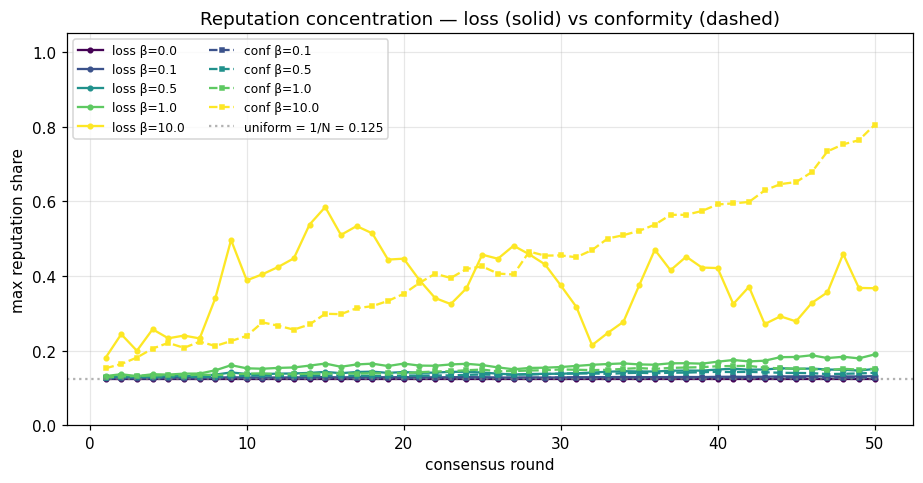

In [4]:
N = d['config']['n_agents']
fig, ax = plt.subplots(figsize=(8.5, 4.5))

def _max_share(h):
    reps = np.asarray(h['reputations'])
    if reps.size == 0:
        return None
    return (reps / reps.sum(axis=1, keepdims=True)).max(axis=1)

for h in loss_runs.values():
    ms = _max_share(h)
    if ms is None:
        continue
    ax.plot(np.arange(1, len(ms) + 1), ms, ls='-', marker='o', markersize=3,
            color=bcolor[h['beta']], label=f"loss β={h['beta']}")
for h in conf_runs.values():
    ms = _max_share(h)
    if ms is None:
        continue
    ax.plot(np.arange(1, len(ms) + 1), ms, ls='--', marker='s', markersize=3,
            color=bcolor[h['beta']], label=f"conf β={h['beta']}")

ax.axhline(1 / N, color='gray', ls=':', alpha=0.6,
           label=f'uniform = 1/N = {1 / N:.3f}')
ax.set_xlabel('consensus round'); ax.set_ylabel('max reputation share')
ax.set_title('Reputation concentration — loss (solid) vs conformity (dashed)')
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

## Summary table

`Δ vs FedAvg` is final accuracy minus the β=0 baseline — positive only
where reputation actually helped.

In [5]:
baseline = loss_runs.get('beta0.0', {}).get('eval_acc', [np.nan])[-1]
rows = []
for name, h in {**loss_runs, **conf_runs}.items():
    reps = np.asarray(h['reputations']) if h.get('reputations') else np.zeros((0, N))
    if reps.size:
        fs = reps[-1] / reps[-1].sum()
        max_share, winner = float(fs.max()), int(fs.argmax())
    else:
        max_share, winner = float('nan'), -1
    rows.append({
        'run':            name,
        'mode':           h.get('mode', 'loss'),
        'β':              h['beta'],
        'final val_acc':  h['eval_acc'][-1],
        'Δ vs FedAvg':    h['eval_acc'][-1] - baseline,
        'final val_loss': h['eval_loss'][-1],
        'max rep share':  max_share,
        'cascade winner': winner,
    })
pd.DataFrame(rows).sort_values(['mode', 'β']).round(4).reset_index(drop=True)

,run,mode,β,final val_acc,Δ vs FedAvg,final val_loss,max rep share,cascade winner
0,conf_beta0.1,conformity,0.1,0.8819,-0.0057,0.3134,0.1270,4
1,conf_beta0.5,conformity,0.5,0.8819,-0.0057,0.3133,0.1402,4
2,conf_beta1.0,conformity,1.0,0.8750,-0.0126,0.3173,0.1512,4
3,conf_beta10.0,conformity,10.0,0.8567,-0.0310,0.3632,0.8042,3
4,beta0.0,loss,0.0,0.8876,0.0000,0.3100,0.1250,0
5,beta0.1,loss,0.1,0.8876,0.0000,0.3072,0.1313,0
6,beta0.5,loss,0.5,0.8853,-0.0023,0.3057,0.1506,0
7,beta1.0,loss,1.0,0.8853,-0.0023,0.3040,0.1895,0
8,beta10.0,loss,10.0,0.8704,-0.0172,0.3256,0.3668,4
